# Project 1

In [80]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [81]:
ticker = "AMD"
print(f"Downloading data for {ticker}")
# Downloading 3 years of daily closing prices
data = yf.download(ticker, start="2021-01-01", end="2024-01-01")['Close']

# Splitting the data for the last 126 trading days (approx. 6 months) for reality checking
holdout_days = 126
train_data = data.iloc[:-holdout_days]
holdout_data = data.iloc[-holdout_days:]


[*********************100%***********************]  1 of 1 completed

In [82]:
# Calculating daily log returns using: r_t = ln(P_t / P_(t-1))
log_returns = np.log(train_data / train_data.shift(1)).dropna()

# Estimating drift (mu) and volatility (sigma) from training data
mu = log_returns.mean()
sigma = log_returns.std()

print(f"Estimated Daily Drift (μ): {mu.iloc[0]:.6f}")
print(f"Estimated Daily Volatility (σ): {sigma.iloc[0]:.6f}")


Estimated Daily Drift (μ): 0.000336
Estimated Daily Volatility (σ): 0.033114


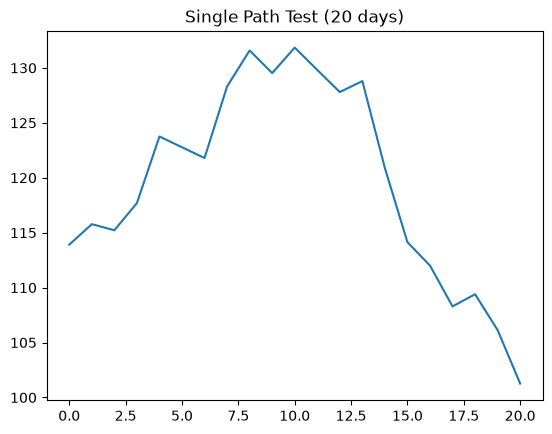

In [83]:
# Single-path GBM simulator function
def simulate_single_path(S0, mu, sigma, steps, seed=42 ):
    """Generates a single price path using a standard loop."""
    path = [S0]
    np.random.seed(seed)
    for _ in range(steps):
        Z = np.random.standard_normal()
        S_next = path[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * Z)
        path.append(S_next)
    return np.array(path)


plt.plot(simulate_single_path(train_data.iloc[-1], mu, sigma, 20))
plt.title("Single Path Test (20 days)")
plt.show()


In [84]:
def simulate_vectorized_paths(S0, mu, sigma, steps, n_paths, seed=42):
    """Generates several independent paths using numpy."""
    # Changing mu and sigma to raw scalars if they are 1-element Series
    m = float(mu.item() if hasattr(mu, "item") else mu) 
    s = float(sigma.item() if hasattr(sigma, "item") else sigma)
    np.random.seed(seed)
    Z = np.random.standard_normal((steps, n_paths))
    drift = m - 0.5 * s**2
    diffusion = s * Z
    daily_growth = np.exp(drift + diffusion)

    starting_row = np.ones((1, n_paths)) # Adding a row of 1s to represent the starting point (growth factor = 1)
    paths = np.vstack([starting_row, np.cumprod(daily_growth, axis=0)]) # Taking the cumulative product down the columns (axis=0)
    
    S0_val = float(S0.item() if hasattr(S0, "item") else S0)# If S0 is a Series, extracting its float value to avoid index matching
    
    return paths * S0_val

S0 = train_data.iloc[-1]  # Price right before the holdout window starts
n_paths = 5000
n_steps = len(holdout_data)

simulated_paths = simulate_vectorized_paths(S0, mu, sigma, n_steps, n_paths)

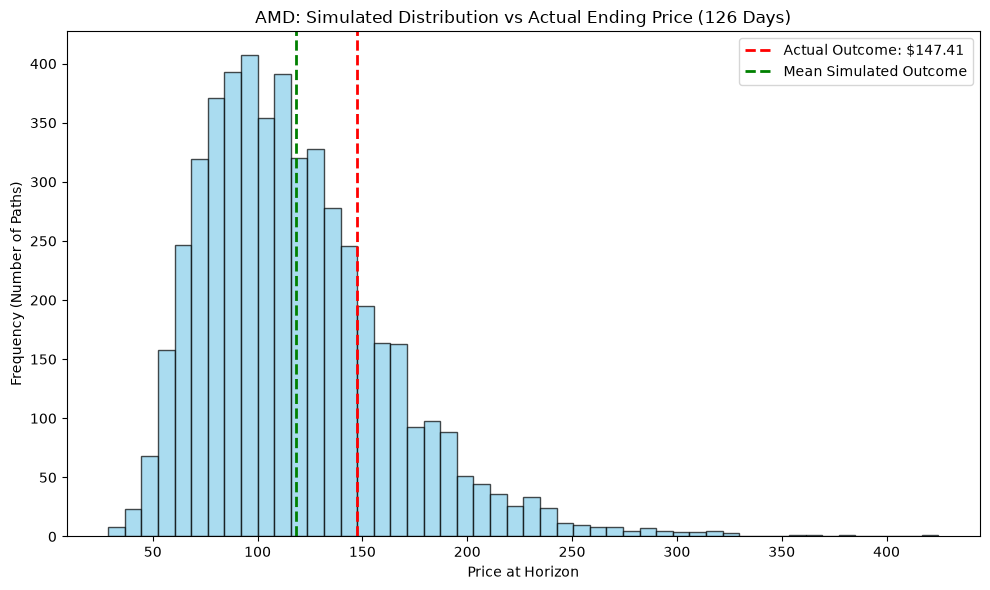

In [85]:
# Comparing the simulated distribution to reality
simulated_final_prices = simulated_paths[-1, :] # Extracting the simulated ending prices (the last row of our 2D array)
actual_final_price = holdout_data.iloc[-1]

percentile = stats.percentileofscore(simulated_final_prices, actual_final_price) # Calculating the percentile of the actual price within our simulated distribution

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(simulated_final_prices, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(actual_final_price.iloc[0], color='red', linestyle='dashed', linewidth=2, 
            label=f'Actual Outcome: ${actual_final_price.iloc[0]:.2f}')
plt.axvline(np.mean(simulated_final_prices), color='green', linestyle='dashed', linewidth=2, 
            label='Mean Simulated Outcome')

plt.title(f'{ticker}: Simulated Distribution vs Actual Ending Price ({n_steps} Days)')
plt.xlabel('Price at Horizon')
plt.ylabel('Frequency (Number of Paths)')
plt.legend()
plt.tight_layout()
plt.show()


In [86]:
# Turning it into a simple Value-at-Risk (VaR) estimate
S0_val = float(S0.item() if hasattr(S0, "item") else S0)
simulated_horizon_returns = (simulated_final_prices - S0_val) / S0_val # Calculating the percentage return of each path over the whole horizon


var_5_pct = np.percentile(simulated_horizon_returns, 5) * 100 # The 5th percentile represents our VaR
var_dollar_loss = S0_val * (abs(var_5_pct) / 100)


In [87]:

# Dynamically generating the finding based on the percentile

finding = (
    f"\nOver the {n_steps}-day holdout window, the simulated paths imply a 5% Value-at-Risk (VaR) of "
    f"{abs(var_5_pct):.2f}% (or ${var_dollar_loss:.2f}), i.e., in 5% of simulated outcomes, the price fell "
    f"by at least this much. The actual ending price of ${actual_final_price.iloc[0]:.2f} landed at the "
    f"{percentile[0]:.1f}th percentile of our simulated Geometric Brownian Motion distribution, within the model's typical range. "
    f"However, this single observation isn't enough on its own to judge calibration; hence, we do a multi-ticker test below.")


print(finding)



Over the 126-day holdout window, the simulated paths imply a 5% Value-at-Risk (VaR) of 47.09% (or $53.64), i.e., in 5% of simulated outcomes, the price fell by at least this much. The actual ending price of $147.41 landed at the 78.1th percentile of our simulated Geometric Brownian Motion distribution, within the model's typical range. However, this single observation isn't enough on its own to judge calibration; hence, we do a multi-ticker test below.


In [88]:
# Testing multiple tickers
def evaluate_ticker_calibration(
    ticker,
    start_date="2021-01-01",
    end_date="2024-01-01",
    holdout_days=126,
    num_paths=5000,
    seed=42):
  """Downloads price history, calculates training volatility (sigma_train) and 
  holdout volatility (sigma_holdout), simulates daily price paths using cumulative
  products over holdout_days, and returns calibration metrics.
  """
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)
  if df.empty:
    raise ValueError(f"No data returned for {ticker}")

  data = (
      df["Close"]
      if "Close" in df.columns
      else (df["Adj Close"] if "Adj Close" in df.columns else df.iloc[:, 0]))
  if isinstance(data, pd.DataFrame):
    data = data.squeeze() # Fixing the DataFrame-vs-Series issue, so that we get a plain float rather than a length-1 pandas object
  data = data.dropna()

  if len(data) <= holdout_days + 30:
    raise ValueError(f"Insufficient history for {ticker}")

  train_data = data.iloc[:-holdout_days]
  holdout_data = data.iloc[-holdout_days:]

  # Computing sigma_train and daily drift (estimation window)
  train_log_returns = np.log(train_data / train_data.shift(1)).dropna()
  mu = float(train_log_returns.mean())
  sigma_train = float(train_log_returns.std())

  # Computing sigma_holdout (testing window)
  holdout_log_returns = np.log(holdout_data / holdout_data.shift(1)).dropna()
  sigma_holdout = float(holdout_log_returns.std())

  S0 = float(train_data.iloc[-1])
  S_realized = float(holdout_data.iloc[-1])
  np.random.seed(seed)

  Z = np.random.standard_normal((num_paths, holdout_days))
  daily_factors = np.exp((mu - 0.5 * sigma_train ** 2) + sigma_train * Z)
  price_paths = S0 * np.cumprod(daily_factors, axis=1)
  S_terminal = price_paths[:, -1]

  # Calculating percentile rank of realized price relative to simulated outcomes
  percentile = float(stats.percentileofscore(S_terminal, S_realized))

  return mu, sigma_train, sigma_holdout, percentile



Running daily path simulation and volatility evaluation across tickers...


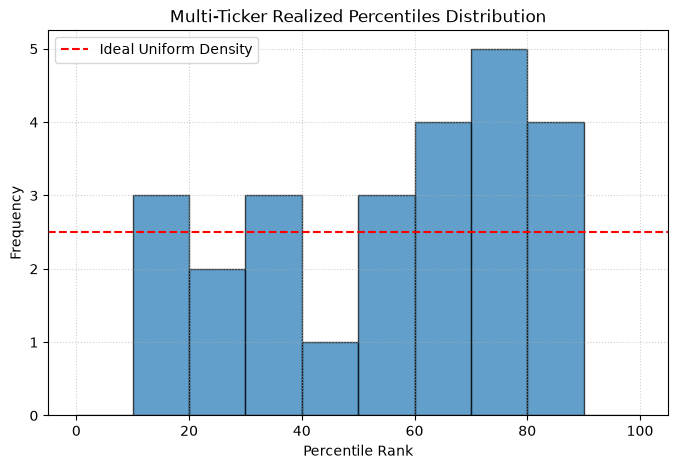

Multi-Ticker KS Statistic: 0.1744, p-value: 0.3876


In [89]:
tickers = ["AAPL","MSFT","NVDA","AMD","AMZN","GOOGL","JPM","BAC","JNJ","PFE","XOM","CVX","PG","KO",
    "TSLA","MCD","DIS","HD","NKE","UNH","COST","BA","CAT","GS","WMT"]

results = []

print("Running daily path simulation and volatility evaluation across tickers...")
for idx, ticker in enumerate(tickers):
  try:
    mu, sigma_tr, sigma_ho, pct = evaluate_ticker_calibration(
        ticker, seed=42 + idx)
    results.append({
        "Ticker": ticker,
        "Estimated_Mu": mu,
        "Sigma_Train": sigma_tr,
        "Sigma_Holdout": sigma_ho,
        "Percentile": pct})
  except Exception as e:
    print(f"Skipping {ticker}: {e}")

results_df = pd.DataFrame(results)

# Testing aggregated percentiles
percentiles = results_df["Percentile"].values

plt.figure(figsize=(8, 5))
plt.hist(percentiles, bins=10, range=(0, 100), edgecolor="black", alpha=0.7)
plt.axhline(
    len(percentiles) / 10,
    color="red",
    linestyle="--",
    label="Ideal Uniform Density")
plt.title("Multi-Ticker Realized Percentiles Distribution")
plt.xlabel("Percentile Rank")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

ks_stat, p_val = stats.kstest(percentiles, "uniform", args=(0, 100))
print(f"Multi-Ticker KS Statistic: {ks_stat:.4f}, p-value: {p_val:.4f}")


In [90]:
results_df["Vol_Ratio"] = results_df["Sigma_Holdout"] / results_df["Sigma_Train"]
display(results_df)

,Ticker,Estimated_Mu,Sigma_Train,Sigma_Holdout,Percentile,Vol_Ratio
0,AAPL,0.000670,0.018421,0.011928,37.66,0.647550
1,MSFT,0.000751,0.018245,0.013408,56.16,0.734880
2,NVDA,0.001874,0.034745,0.022790,49.44,0.655926
3,AMD,0.000336,0.033114,0.026059,78.26,0.786933
4,AMZN,-0.000321,0.024377,0.019175,79.86,0.786595
5,GOOGL,0.000522,0.020495,0.017440,69.32,0.850934
6,JPM,0.000344,0.016248,0.009512,78.60,0.585441
7,BAC,0.000017,0.018220,0.016230,83.10,0.890812
8,JNJ,0.000194,0.010020,0.010976,29.74,1.095370
9,PFE,0.000139,0.016091,0.015694,10.52,0.975306


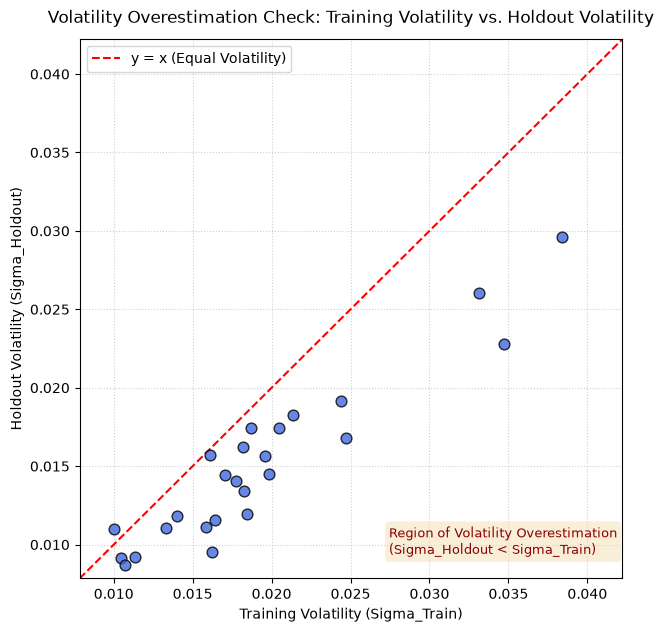

VOLATILITY RATIO SUMMARY
.........................
Median Volatility Ratio: 0.7995
Tickers with Ratio < 1.0: 96.0%


In [91]:
# Scatter Plot (Sigma_Train vs. Sigma_Holdout)
plt.figure(figsize=(7, 7))
plt.scatter(
    results_df["Sigma_Train"],
    results_df["Sigma_Holdout"],
    color="royalblue",
    edgecolor="black",
    s=60,
    alpha=0.8,
    zorder=3)

# Reference line y = x
min_val = (
    min(results_df["Sigma_Train"].min(), results_df["Sigma_Holdout"].min())
    * 0.9)
max_val = (
    max(results_df["Sigma_Train"].max(), results_df["Sigma_Holdout"].max())
    * 1.1)
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=1.5,
    label="y = x (Equal Volatility)",
    zorder=2)

plt.title(
    "Volatility Overestimation Check: Training Volatility vs. Holdout"
    " Volatility",
    fontsize=12,
    pad=12)
plt.xlabel("Training Volatility (Sigma_Train)", fontsize=10)
plt.ylabel("Holdout Volatility (Sigma_Holdout)", fontsize=10)
plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])
plt.grid(True, linestyle=":", alpha=0.6, zorder=1)
plt.legend(loc="upper left")

plt.text(
    max_val * 0.65,
    min_val * 1.2,
    "Region of Volatility Overestimation\n(Sigma_Holdout < Sigma_Train)",
    color="darkred",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5, edgecolor="none"
    ))

plt.show()

# Quantitative Ratio Summary

median_ratio = results_df["Vol_Ratio"].median()
fraction_below_1 = (results_df["Vol_Ratio"] < 1.0).mean() * 100

print("VOLATILITY RATIO SUMMARY")
print(".........................")
print(f"Median Volatility Ratio: {median_ratio:.4f}")
print(f"Tickers with Ratio < 1.0: {fraction_below_1:.1f}%")